# Housing Price Prediction — Exploratory Data Analysis

## Purpose of this notebook

The goal of this project is to build a machine learning model that predicts the median house value of a California district from demographic and housing-related features.

This notebook is not only for producing plots. It documents the reasoning process behind the model:

- understand what data we have
- inspect its quality and structure
- look for distributions and unusual values
- investigate relationships between features and the target
- form hypotheses before modeling
- prepare the data for a first baseline model

The important habit is to ask **why** we are performing each operation rather than treating the code as a sequence of commands to execute.


## 1. Import the tools we need

We begin by importing the Python libraries used throughout the analysis.

`pandas` will let us work with the dataset as a table, `numpy` provides numerical operations, and `matplotlib` will allow us to visualize distributions and relationships.

The purpose of importing these libraries at the beginning is to make the notebook's dependencies explicit.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

In [3]:
housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

## 3. Get a first look at the data

The first few rows give us an immediate idea of what one observation looks like.

Each row represents a housing district, while each column contains a feature describing that district or the target we eventually want to predict.

This is only a first inspection. A few rows cannot tell us whether the dataset is clean or representative, so we continue with structural checks.


In [4]:
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [5]:
df.shape

(20640, 9)

In [6]:
df.info

<bound method DataFrame.info of        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       

## 5. Examine numerical distributions

`describe()` gives summary statistics such as the mean, standard deviation, quartiles, and maximum.

The quartiles are particularly useful because they describe the central part of the distribution. Comparing the maximum with the upper quartile and mean can reveal unusually large observations.

Earlier in this analysis, some variables such as `AveOccup` showed extreme maximum values. Rather than automatically deleting them, we investigate whether they are plausible and what effect they may have.


In [7]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [8]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## 7. Visualize the distributions

Numerical summary statistics are useful, but plots often make patterns much easier to see.

Histograms show how observations are distributed across ranges of values. They can reveal skewness, concentration, long tails, unusual values, and possible clipping or limits in the data.

This is why visualization is part of the reasoning process rather than decoration.


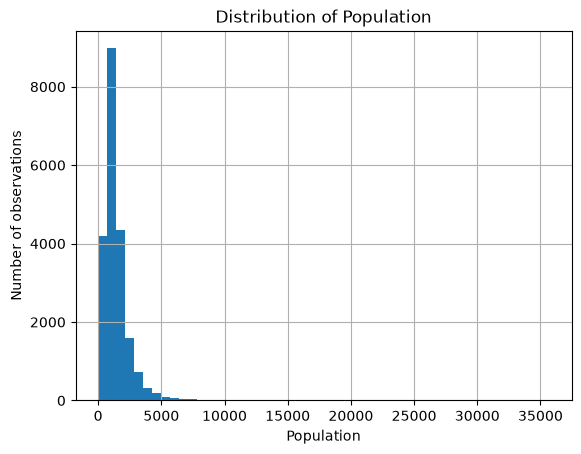

In [9]:
df["Population"].hist(bins=50)
plt.xlabel("Population")
plt.ylabel("Number of observations")
plt.title("Distribution of Population")
plt.show()

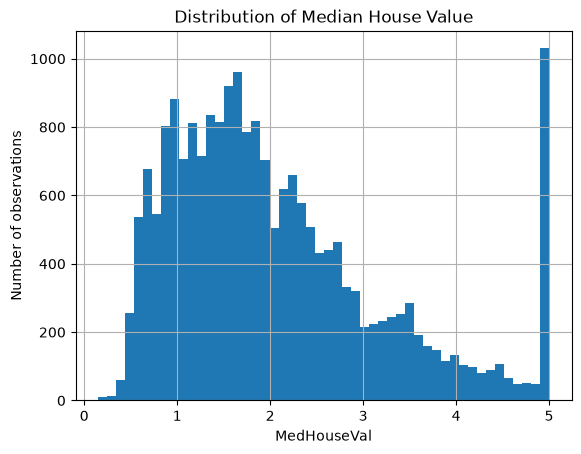

In [10]:
df["MedHouseVal"].hist(bins=50)
plt.xlabel("MedHouseVal")
plt.ylabel("Number of observations")
plt.title("Distribution of Median House Value")
plt.show()

In [11]:
corr = df.corr(numeric_only=True)
corr["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

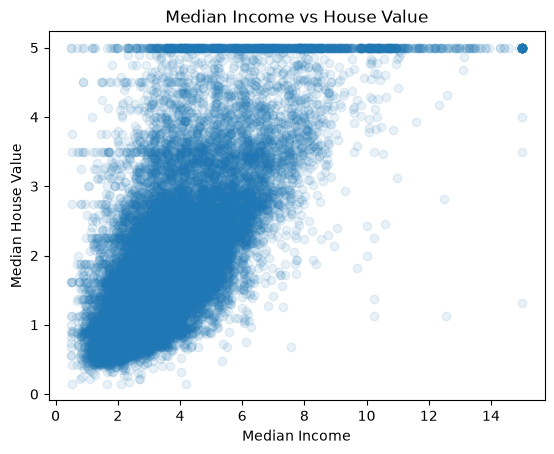

In [12]:
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.1)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs House Value")
plt.show()

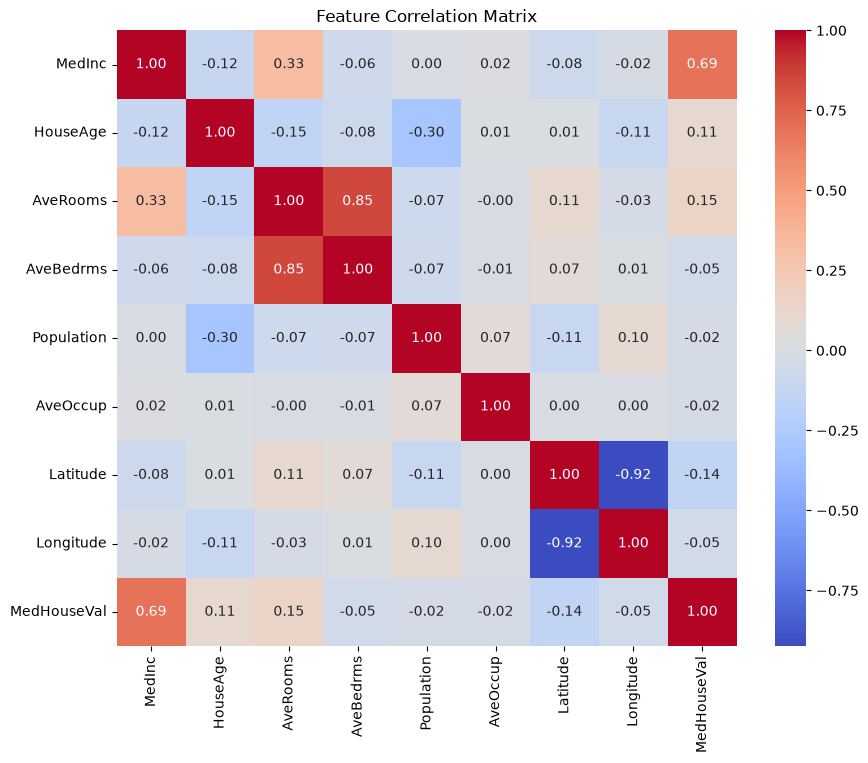

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

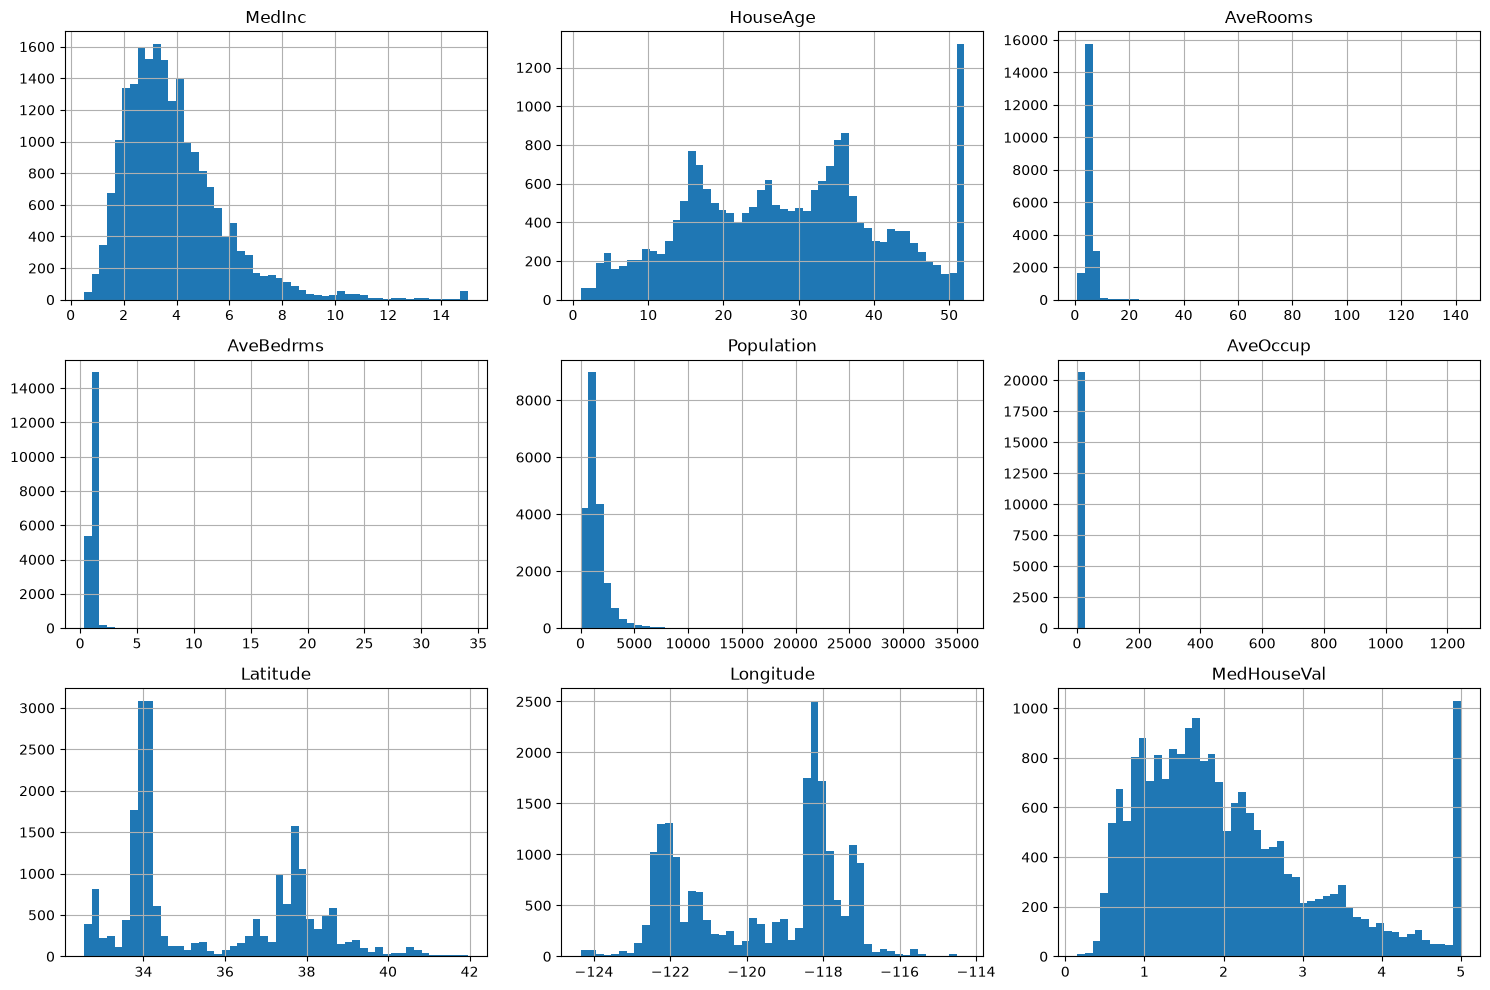

In [14]:
df.hist(bins = 50, figsize = (15, 10))
plt.tight_layout()
plt.show()

In [15]:
df["AveOccup"]

0        2.555556
1        2.109842
2        2.802260
3        2.547945
4        2.181467
           ...   
20635    2.560606
20636    3.122807
20637    2.325635
20638    2.123209
20639    2.616981
Name: AveOccup, Length: 20640, dtype: float64

In [16]:
df["AveOccup"].sort_values(ascending = False).head(10)

19006    1243.333333
3364      599.714286
16669     502.461538
13034     230.172414
9172       83.171429
12104      63.750000
16420      51.400000
8874       41.214286
13366      33.952941
5986       21.333333
Name: AveOccup, dtype: float64

In [17]:
df.loc[[19006, 3364, 16669, 13034, 9172]]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
19006,10.2264,45.0,3.166667,0.833333,7460.0,1243.333333,38.32,-121.98,1.375
3364,5.5179,36.0,5.142857,1.142857,4198.0,599.714286,40.41,-120.51,0.675
16669,4.2639,46.0,9.076923,1.307692,6532.0,502.461538,35.32,-120.70,3.500
13034,6.1359,52.0,8.275862,1.517241,6675.0,230.172414,38.69,-121.15,2.250
9172,4.2391,5.0,5.123810,0.933333,8733.0,83.171429,34.47,-118.59,1.546


In [18]:
df.loc[[19006, 3364, 16669, 13034, 9172], ["Population", "AveOccup", "MedHouseVal"]]

,Population,AveOccup,MedHouseVal
19006,7460.0,1243.333333,1.375
3364,4198.0,599.714286,0.675
16669,6532.0,502.461538,3.500
13034,6675.0,230.172414,2.250
9172,8733.0,83.171429,1.546


In [19]:
(df["AveOccup"] > 20).sum()

np.int64(10)

In [20]:
(df["AveOccup"] > 20).mean()*100

np.float64(0.04844961240310078)

In [21]:
X= df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [22]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [23]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

## 8. Separate training and test data

Before fitting a model, we need to reserve some observations that the model will not see during training.

The training set is used to learn the model parameters. The test set is held back until evaluation so that we can measure how well the learned relationship generalizes to unseen observations.

This distinction is fundamental to machine learning. A model that performs well only on the data it memorized is not useful in the real world.


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [25]:
X_train.shape

(16512, 8)

In [26]:
X_test.shape

(4128, 8)

## 9. Establish a baseline model

We now build a simple linear regression model using Scikit-learn.

The purpose of a baseline is not to produce the final model. It gives us a reference point against which future improvements can be measured.

With eight features, our model has the form:

$$
\hat y = w_1x_1+w_2x_2+\cdots+w_8x_8+b
$$

The model learns the weights and intercept from the training data.


In [27]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [28]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [29]:
y_pred = model.predict(X_test)

In [30]:
y_pred[:10]

array([0.71912284, 1.76401657, 2.70965883, 2.83892593, 2.60465725,
       2.01175367, 2.64550005, 2.16875532, 2.74074644, 3.91561473])

In [31]:
y_test.iloc[:10].values

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

## 10. Evaluate the baseline

We need numerical metrics to determine how well the model predicts unseen house values.

MAE answers:

> On average, how far are the predictions from the actual values?

Because `MedHouseVal` is measured in units of $100,000, an MAE of about 0.53 corresponds to an average absolute error of roughly $53,000.

We also calculate MSE and RMSE because they treat large errors differently and provide complementary information.


In [32]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
mae

0.5332001304956555

In [33]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
mse

0.5558915986952442

In [34]:
rmse = np.sqrt(mse)
rmse

np.float64(0.7455813830127763)

## 11. Interpret R²

R² answers a different question from MAE and RMSE.

It compares our model with a simple baseline that predicts the mean target value for every observation.

An R² of approximately 0.576 means that the linear model explains about 57.6% of the overall variation in house values relative to that mean-prediction baseline.

It does **not** mean that 57.6% of houses were predicted correctly.


In [35]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2

0.575787706032451

In [36]:
model.intercept_

np.float64(-37.02327770606416)

## 12. Inspect the learned equation

The fitted model has learned one coefficient for each feature and an intercept.

These coefficients form the actual equation used to make predictions:

$$
\hat y = w_1x_1+w_2x_2+\cdots+w_8x_8+b
$$

Looking at the coefficients helps us move beyond treating Scikit-learn as a black box. We can see the numerical parameters that define the model.

However, raw coefficient magnitudes should not automatically be interpreted as feature importance because the features use very different units and can be correlated with one another.


In [37]:
model.coef_

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [38]:
coefficients = pd.Series(model.coef_, index = X.columns)
coefficients

MedInc        0.448675
HouseAge      0.009724
AveRooms     -0.123323
AveBedrms     0.783145
Population   -0.000002
AveOccup     -0.003526
Latitude     -0.419792
Longitude    -0.433708
dtype: float64

In [39]:
X_test.iloc[0]

MedInc           1.681200
HouseAge        25.000000
AveRooms         4.192201
AveBedrms        1.022284
Population    1392.000000
AveOccup         3.877437
Latitude        36.060000
Longitude     -119.010000
Name: 20046, dtype: float64

In [40]:
y_test.iloc[0]

np.float64(0.477)

In [41]:
model.predict(X_test)

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251], shape=(4128,))

## Current conclusion

We have completed the exploratory analysis and established a first linear-regression baseline.

The baseline is useful because it gives us a measurable starting point. We now know how the data is structured, which relationships appear important, how the target behaves, and how a basic linear model performs.

The next stage is deliberately educational: instead of immediately using a more complicated algorithm, we will implement the core mathematics of linear regression ourselves. That will connect the equation

$$
\hat y=\mathbf w^T\mathbf x+b
$$

with the loss function, gradients, and gradient descent.

The goal is to understand **how the parameters are learned**, not merely how to call a library function.
